In [1]:
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

import kagglehub

warnings.filterwarnings("ignore")


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
dataset_root = kagglehub.dataset_download(
    "tombackert/brain-tumor-mri-data"
)

dataset_path = Path(dataset_root) / "brain-tumor-mri-dataset"

print("Dataset path:")
print(dataset_path)

print("\nClass folders:")
print(
    sorted([
        folder.name
        for folder in dataset_path.iterdir()
        if folder.is_dir()
    ])
)

Dataset path:
C:\Users\HP\.cache\kagglehub\datasets\tombackert\brain-tumor-mri-data\versions\1\brain-tumor-mri-dataset

Class folders:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

filepaths = []
labels = []

for label in CLASS_NAMES:

    label_path = dataset_path / label

    if not label_path.is_dir():
        raise FileNotFoundError(
            f"Missing class folder: {label_path}"
        )

    for image_path in label_path.rglob("*"):

        if (
            image_path.is_file()
            and image_path.suffix.lower()
            in IMAGE_EXTENSIONS
        ):
            filepaths.append(str(image_path))
            labels.append(label)
    

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print("Total images:", len(df))

print("\nImages per class:")
print(
    df["label"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

Total images: 7153

Images per class:
label
glioma        1621
meningioma    1775
notumor       2000
pituitary     1757
Name: count, dtype: int64


label
glioma        1621
meningioma    1775
notumor       2000
pituitary     1757
Name: count, dtype: int64


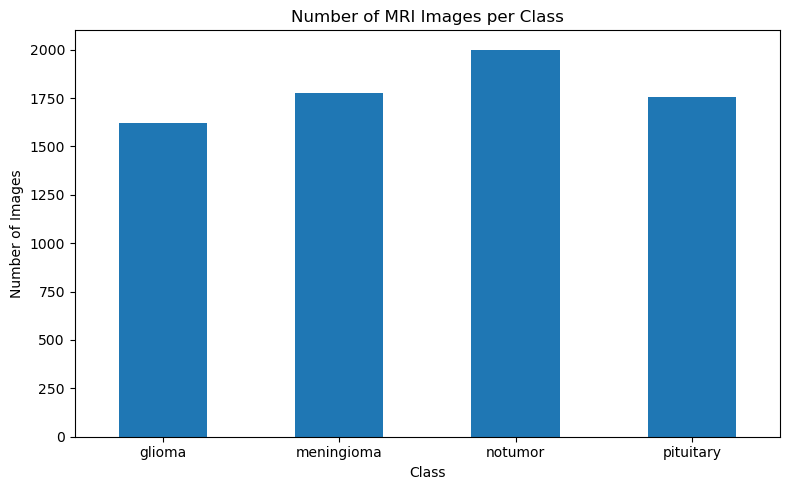

In [4]:
class_counts = (
    df["label"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print(class_counts)

plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("Number of MRI Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [5]:
print("Missing values:")
print(
    df[["filepath", "label"]].isnull().sum()
)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate file paths:")

print(
    df["filepath"].duplicated().sum()
)

bad_images = []
image_sizes = []

for filepath in df["filepath"]:

    try:

        with Image.open(filepath) as img:
            img.verify()

        with Image.open(filepath) as img:
            image_sizes.append(img.size)

    except Exception:

        bad_images.append(filepath)


print("\nCorrupted/unreadable images:")
print(len(bad_images))

print("\nMost common image sizes:")
print(
    pd.Series(image_sizes)
    .value_counts()
    .head()
)

Missing values:
filepath    0
label       0
dtype: int64

Duplicate rows:
0

Duplicate file paths:
0

Corrupted/unreadable images:
0

Most common image sizes:
(512, 512)    4859
(225, 225)     334
(630, 630)      90
(236, 236)      81
(201, 251)      59
Name: count, dtype: int64


In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED,
    shuffle=True
)


train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=SEED,
    shuffle=True
)

print(f"Training:   {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Testing:    {len(test_df)}")

Training:   4577
Validation: 1145
Testing:    1431


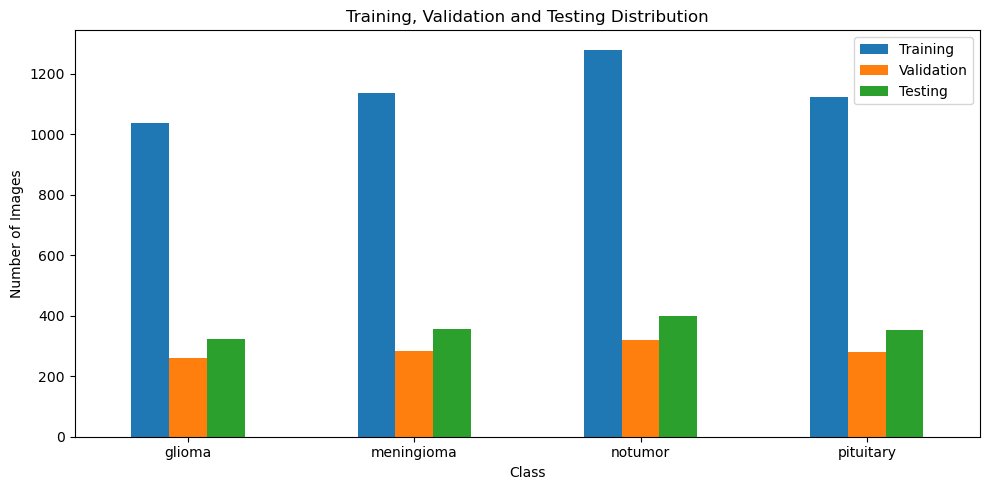

In [7]:
split_counts = pd.DataFrame({

    "Training":
        train_df["label"]
        .value_counts()
        .reindex(CLASS_NAMES),

    "Validation":
        val_df["label"]
        .value_counts()
        .reindex(CLASS_NAMES),

    "Testing":
        test_df["label"]
        .value_counts()
        .reindex(CLASS_NAMES)
})

split_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Training, Validation and Testing Distribution"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

Found 4577 validated image filenames belonging to 4 classes.


In [9]:
val_generator = val_test_datagen.flow_from_dataframe(

    dataframe=val_df,

    x_col="filepath",
    y_col="label",

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    classes=CLASS_NAMES,

    shuffle=False
)

Found 1145 validated image filenames belonging to 4 classes.


In [10]:
test_generator = val_test_datagen.flow_from_dataframe(

    dataframe=test_df,

    x_col="filepath",
    y_col="label",

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    classes=CLASS_NAMES,

    shuffle=False
)

Found 1431 validated image filenames belonging to 4 classes.


In [11]:
print("Training mapping:")
print(train_generator.class_indices)

print("\nValidation mapping:")
print(val_generator.class_indices)

print("\nTest mapping:")
print(test_generator.class_indices)

Training mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Validation mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Test mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [12]:
train_generator.reset()

images, labels = next(train_generator)

print("Image batch shape:")
print(images.shape)

print("\nLabel batch shape:")
print(labels.shape)

print("\nPixel range:")
print(
    float(images.min()),
    "to",
    float(images.max())
)

train_generator.reset()

Image batch shape:
(32, 224, 224, 3)

Label batch shape:
(32, 4)

Pixel range:
0.0 to 255.0


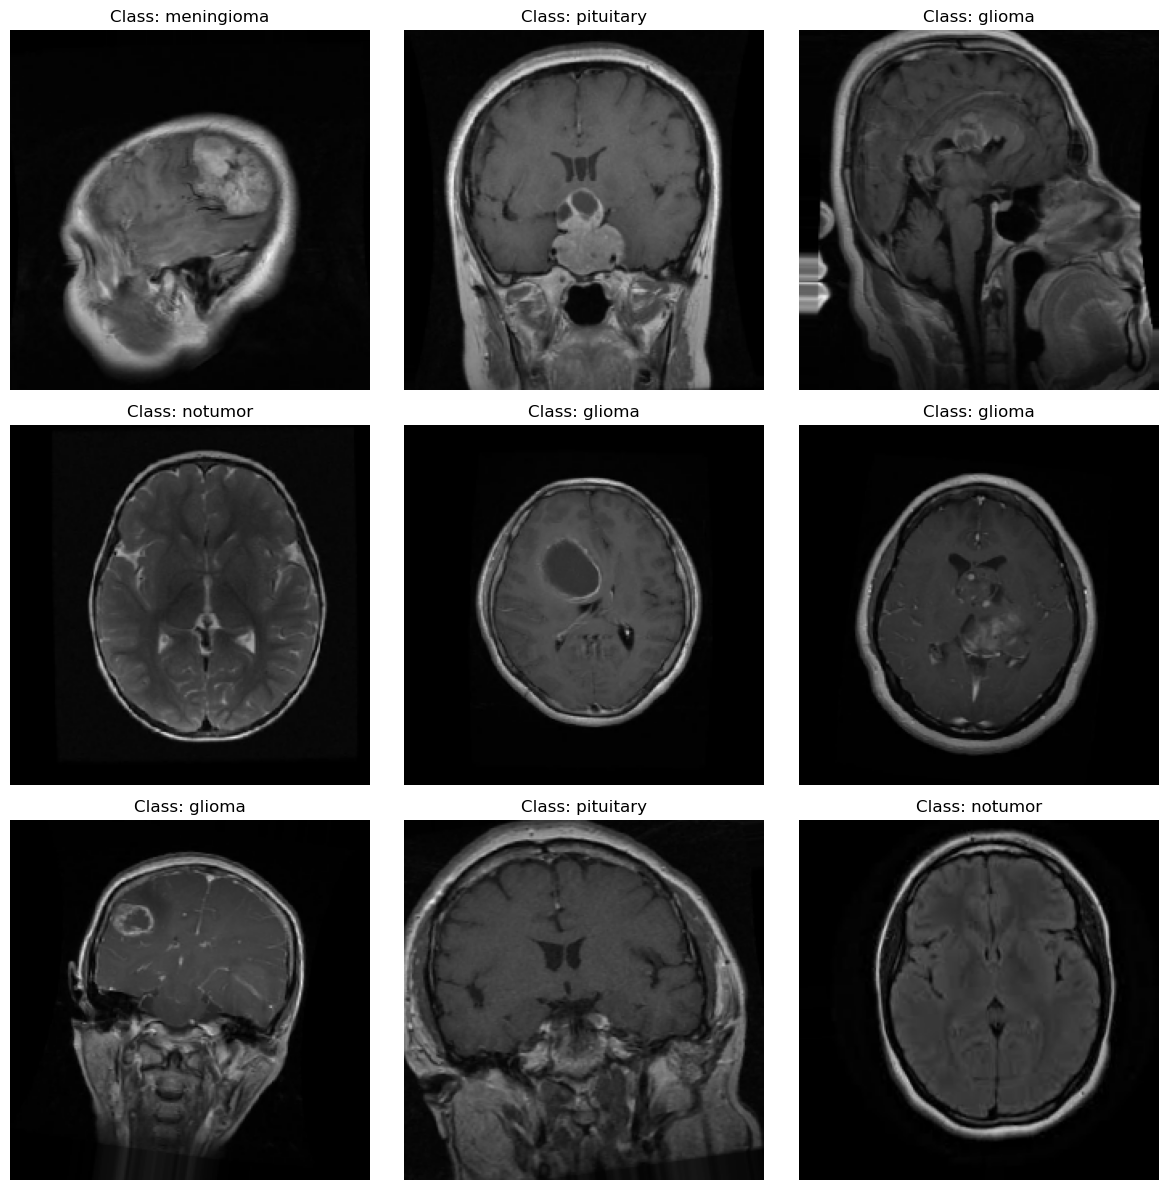

In [13]:

plt.figure(figsize=(12, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    
    display_image = np.clip(
        images[i],
        0,
        255
    ).astype(np.uint8)

    plt.imshow(display_image)

    class_index = np.argmax(labels[i])

    plt.title(
        f"Class: {CLASS_NAMES[class_index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
base_model = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

In [15]:
inputs = tf.keras.Input(
    shape=(*IMG_SIZE, 3)
)

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="gap"
)(x)

x = layers.Dropout(
    0.4,
    name="dropout_1"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    name="dense_1"
)(x)

x = layers.Dropout(
    0.3,
    name="dropout_2"
)(x)

outputs = layers.Dense(
    len(CLASS_NAMES),
    activation="softmax",
    name="predictions"
)(x)

model = Model(
    inputs,
    outputs,
    name="brain_tumor_classifier"
)

model.summary()

Model: "brain_tumor_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)         │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
checkpoint_path = "best_brain_tumor_model.keras"

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [18]:
#PHASE 1

print("=" * 60)
print("PHASE 1: TRAINING CLASSIFICATION HEAD")
print("=" * 60)

base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

PHASE 1: TRAINING CLASSIFICATION HEAD
Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - accuracy: 0.7387 - loss: 0.6413
Epoch 1: val_accuracy improved from None to 0.79738, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.7387 - loss: 0.6413 - val_accuracy: 0.7974 - val_loss: 0.5033 - learning_rate: 0.0010
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8256 - loss: 0.4410
Epoch 2: val_accuracy improved from 0.79738 to 0.86201, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.8256 - loss: 0.4410 - val_accuracy: 0.8620 - val_loss: 0.3938 - learning_rate: 0.0010
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8342 - loss: 0.4226
Epoch 3: val_accuracy improved from 0.86201 to 0.86288, saving model to best_brain_tumor_mode

In [19]:
# PHASE 2


print("\n" + "=" * 60)
print("PHASE 2: FINE-TUNING EFFICIENTNETB0")
print("=" * 60)

base_model.trainable = True


for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True


for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)


PHASE 2: FINE-TUNING EFFICIENTNETB0
Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8951 - loss: 0.2651
Epoch 1: val_accuracy improved from 0.90480 to 0.90742, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.8951 - loss: 0.2651 - val_accuracy: 0.9074 - val_loss: 0.2424 - learning_rate: 1.0000e-05
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9021 - loss: 0.2547
Epoch 2: val_accuracy improved from 0.90742 to 0.91092, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9021 - loss: 0.2547 - val_accuracy: 0.9109 - val_loss: 0.2361 - learning_rate: 1.0000e-05
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9023 - loss: 0.2452
Epoch 3: val_accuracy did not improve from 0.91092
144/144 ━━━━━━━━━━━━━━━━━━━━ 186s 1

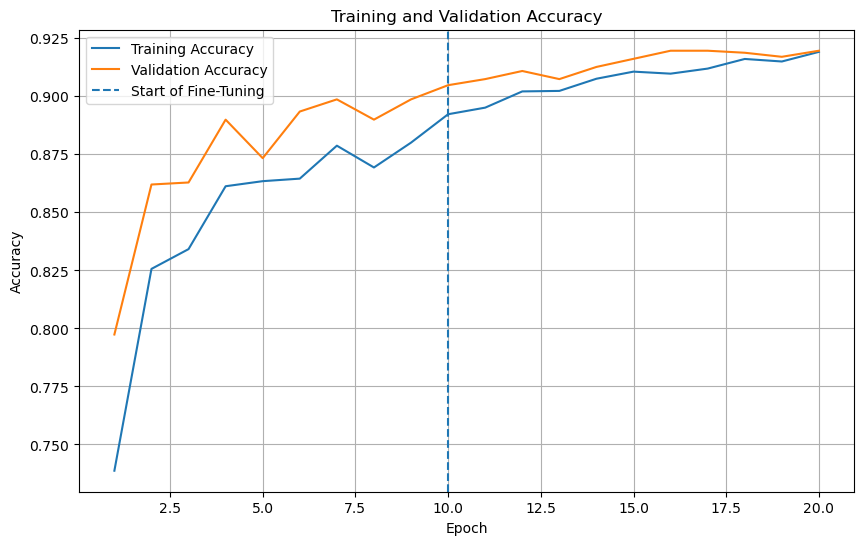

In [20]:
# Combine training histories

train_accuracy = (
    history_phase1.history["accuracy"]
    + history_phase2.history["accuracy"]
)

val_accuracy = (
    history_phase1.history["val_accuracy"]
    + history_phase2.history["val_accuracy"]
)

epochs_range = range(
    1,
    len(train_accuracy) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy,
    label="Validation Accuracy"
)

plt.axvline(
    x=len(history_phase1.history["accuracy"]),
    linestyle="--",
    label="Start of Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)
plt.show()

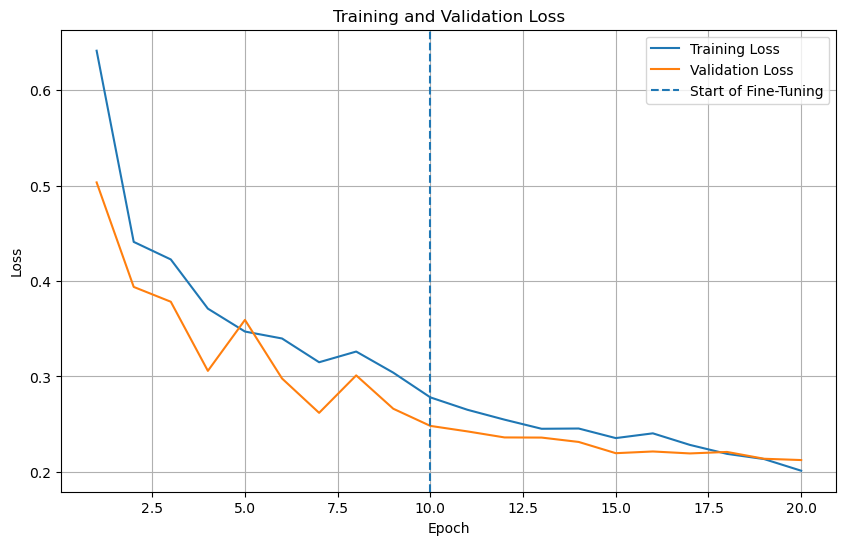

In [21]:
train_loss = (
    history_phase1.history["loss"]
    + history_phase2.history["loss"]
)

val_loss = (
    history_phase1.history["val_loss"]
    + history_phase2.history["val_loss"]
)

epochs_range = range(
    1,
    len(train_loss) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_loss,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss"
)

plt.axvline(
    x=len(history_phase1.history["loss"]),
    linestyle="--",
    label="Start of Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)
plt.show()

In [22]:
test_generator.reset()

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 873ms/step - accuracy: 0.9308 - loss: 0.1915
Test Loss: 0.1915
Test Accuracy: 93.08%


In [23]:
test_generator.reset()

predictions = model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = test_generator.classes

45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 928ms/step


In [24]:
print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(
    f"\nMacro F1-score: {macro_f1:.4f}"
)

Classification Report:

              precision    recall  f1-score   support

      glioma     0.9524    0.8642    0.9061       324
  meningioma     0.8757    0.8732    0.8745       355
     notumor     0.9899    0.9825    0.9862       400
   pituitary     0.9041    0.9915    0.9458       352

    accuracy                         0.9308      1431
   macro avg     0.9305    0.9279    0.9282      1431
weighted avg     0.9320    0.9308    0.9304      1431


Macro F1-score: 0.9282


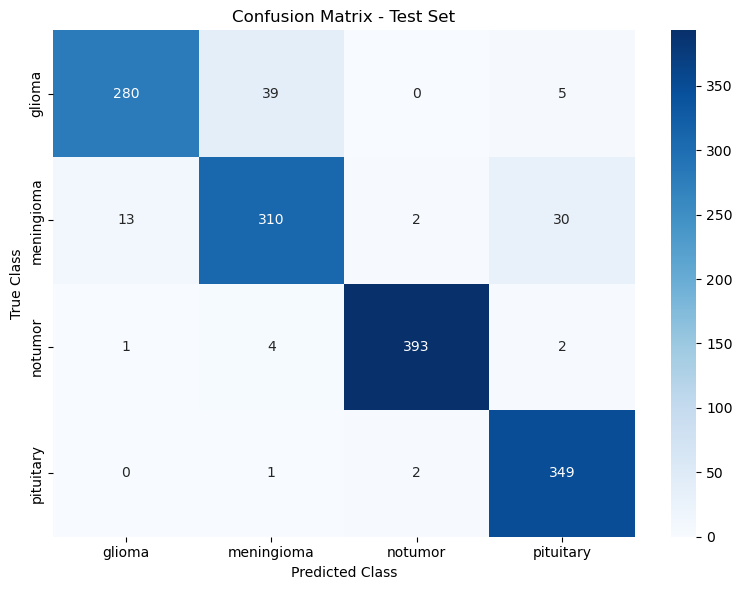

In [25]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 6))



sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)


plt.xlabel("Predicted Class")

plt.ylabel("True Class")

plt.title(
    "Confusion Matrix - Test Set"
)

plt.tight_layout()

plt.show()

In [26]:
print("Model layers:")
for layer in model.layers:
    print(layer.name)

Model layers:
input_layer_1
efficientnetb0
gap
dropout_1
dense_1
dropout_2
predictions


In [27]:
def make_gradcam_heatmap(
    img_array,
    model,
    base_model,
    pred_index=None
):

    # Find the last suitable 4D feature layer
    last_conv_layer = None

    for layer in reversed(base_model.layers):

        try:
            if len(layer.output.shape) == 4:
                last_conv_layer = layer
                break
        except Exception:
            continue

    if last_conv_layer is None:
        raise ValueError(
            "Could not find a suitable feature layer "
            "inside EfficientNet."
        )

    # Model that produces the feature maps
    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    with tf.GradientTape() as tape:

        conv_outputs = conv_model(
            img_array,
            training=False
        )

        tape.watch(conv_outputs)

        x = model.get_layer("gap")(
            conv_outputs
        )

        x = model.get_layer("dropout_1")(
            x,
            training=False
        )

        x = model.get_layer("dense_1")(
            x
        )

        x = model.get_layer("dropout_2")(
            x,
            training=False
        )

        predictions = model.get_layer(
            "predictions"
        )(x)

        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[
            :,
            pred_index
        ]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    if grads is None:
        raise ValueError(
            "Gradients could not be computed. "
            "Check the model connectivity."
        )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    max_value = tf.reduce_max(
        heatmap
    )

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy()

In [28]:
def display_gradcam(
    image_path,
    model,
    base_model,
    class_names,
    alpha=0.4
):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(
        image
    )

    input_array = np.expand_dims(
        image_array,
        axis=0
    )

    predictions = model.predict(
        input_array,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(predictions)
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = float(
        predictions[predicted_index]
    )

    heatmap = make_gradcam_heatmap(
        input_array,
        model,
        base_model,
        pred_index=predicted_index
    )

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        IMG_SIZE
    ).numpy().squeeze()

    plt.figure(figsize=(15, 5))

    
    plt.subplot(1, 3, 1)

    plt.imshow(
        image_array.astype(np.uint8)
    )

    plt.title("Original MRI")
    plt.axis("off")

    
    plt.subplot(1, 3, 2)

    plt.imshow(
        heatmap_resized,
        cmap="jet"
    )

    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    
    plt.subplot(1, 3, 3)

    plt.imshow(
        image_array.astype(np.uint8)
    )

    plt.imshow(
        heatmap_resized,
        cmap="jet",
        alpha=alpha
    )

    plt.title(
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return (
        predicted_class,
        confidence,
        heatmap
    )

Testing Grad-CAM on:
C:\Users\HP\.cache\kagglehub\datasets\tombackert\brain-tumor-mri-data\versions\1\brain-tumor-mri-dataset\pituitary\pi-0656.jpg

Actual class:
pituitary


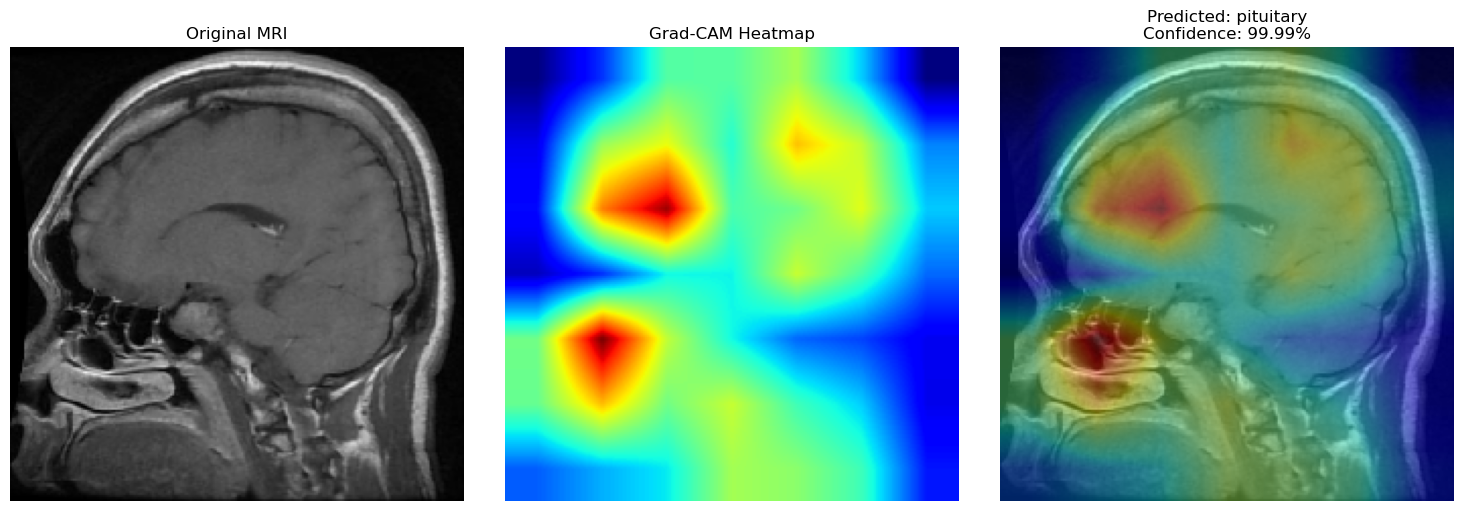


Final result:
Actual: pituitary
Predicted: pituitary
Confidence: 99.99%


In [29]:
sample_path = test_df.iloc[0]["filepath"]

actual_class = test_df.iloc[0]["label"]

print("Testing Grad-CAM on:")
print(sample_path)

print("\nActual class:")
print(actual_class)

predicted_class, confidence, heatmap = display_gradcam(
    image_path=sample_path,
    model=model,
    base_model=base_model,
    class_names=CLASS_NAMES
)

print("\nFinal result:")
print("Actual:", actual_class)
print("Predicted:", predicted_class)
print(
    f"Confidence: {confidence * 100:.2f}%"
)

In [30]:
samples = []

for class_name in CLASS_NAMES:

    class_images = test_df[
        test_df["label"] == class_name
    ]

    if len(class_images) > 0:

        samples.append(
            class_images.iloc[0]["filepath"]
        )


Actual class: glioma


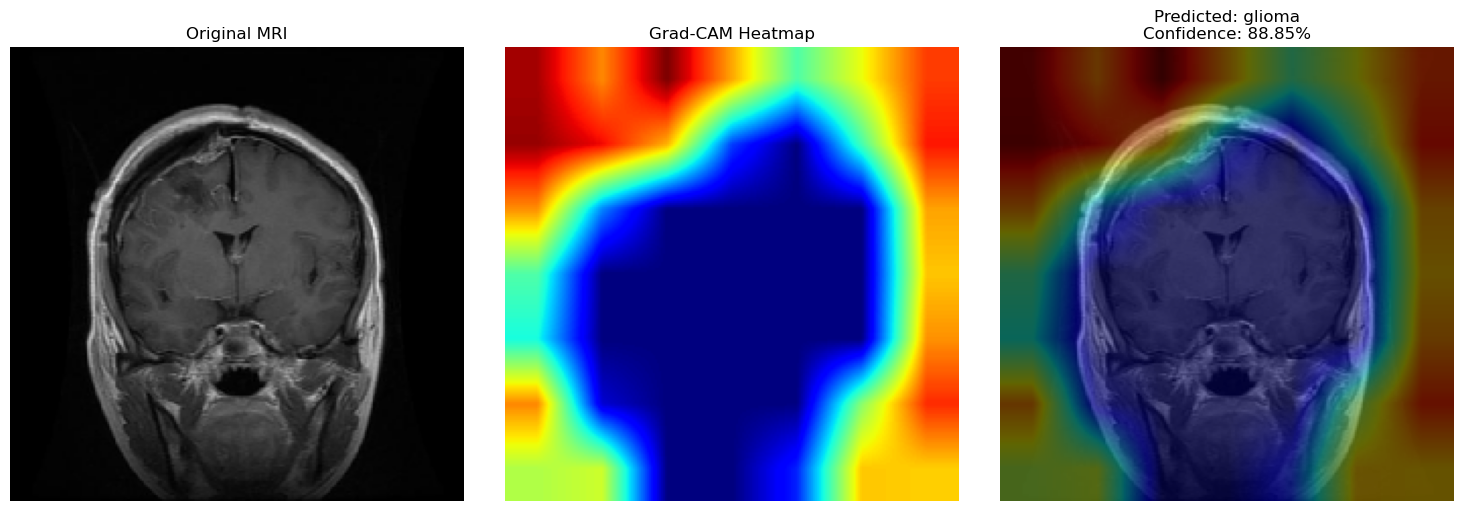

Predicted class: glioma
Confidence: 88.85%

Actual class: meningioma


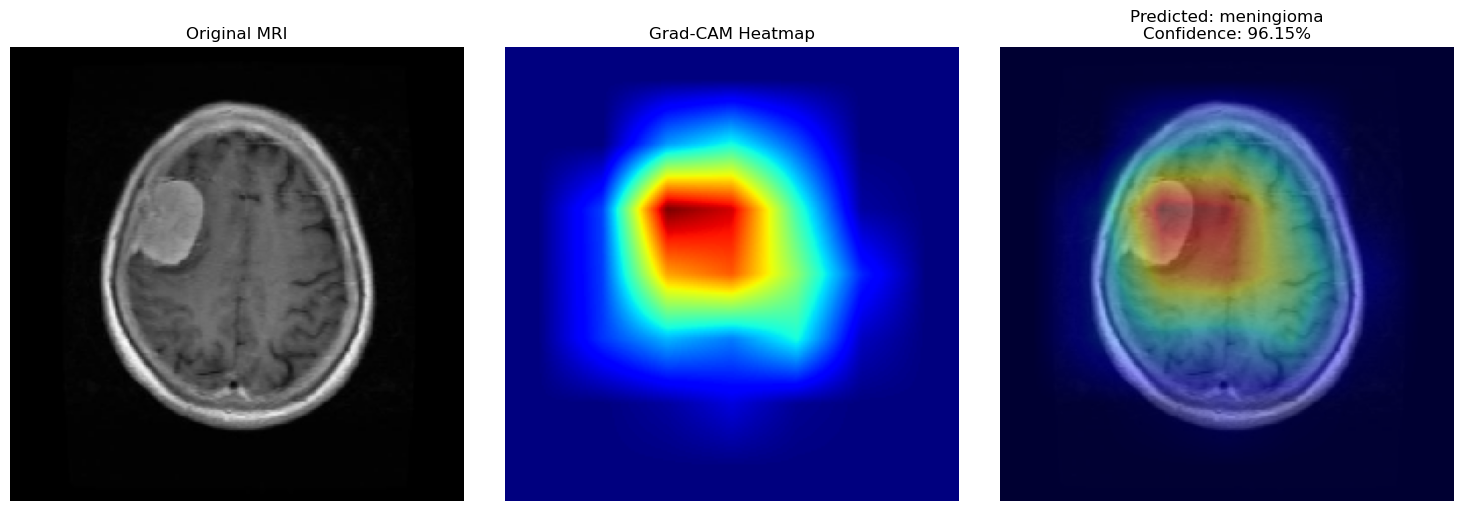

Predicted class: meningioma
Confidence: 96.15%

Actual class: notumor


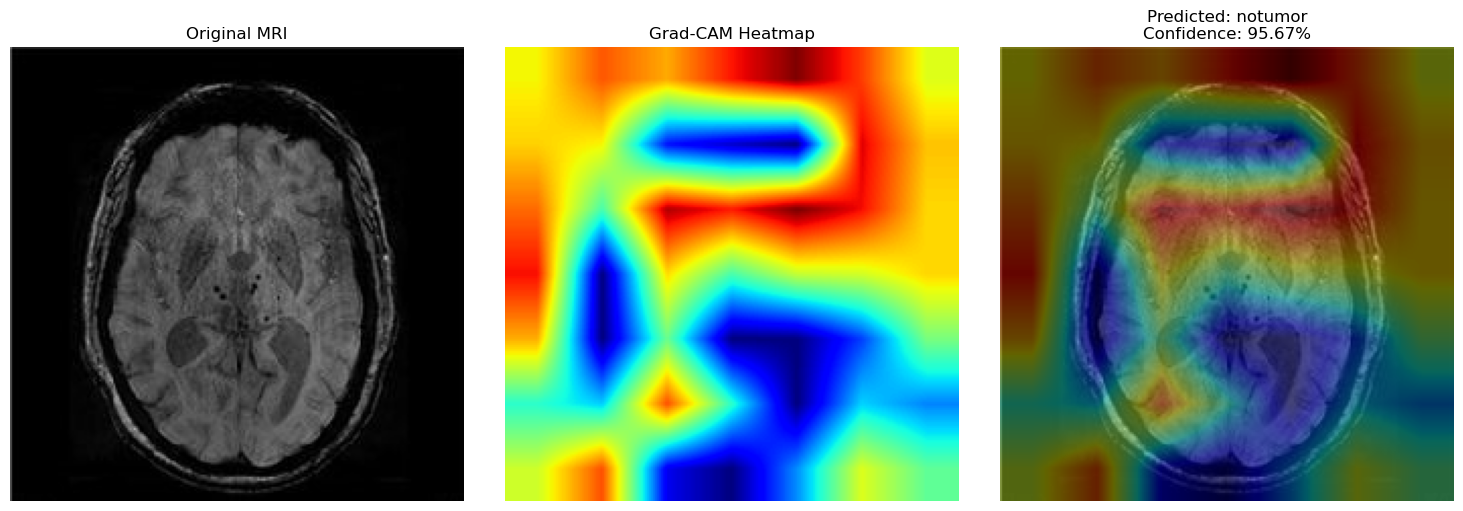

Predicted class: notumor
Confidence: 95.67%

Actual class: pituitary


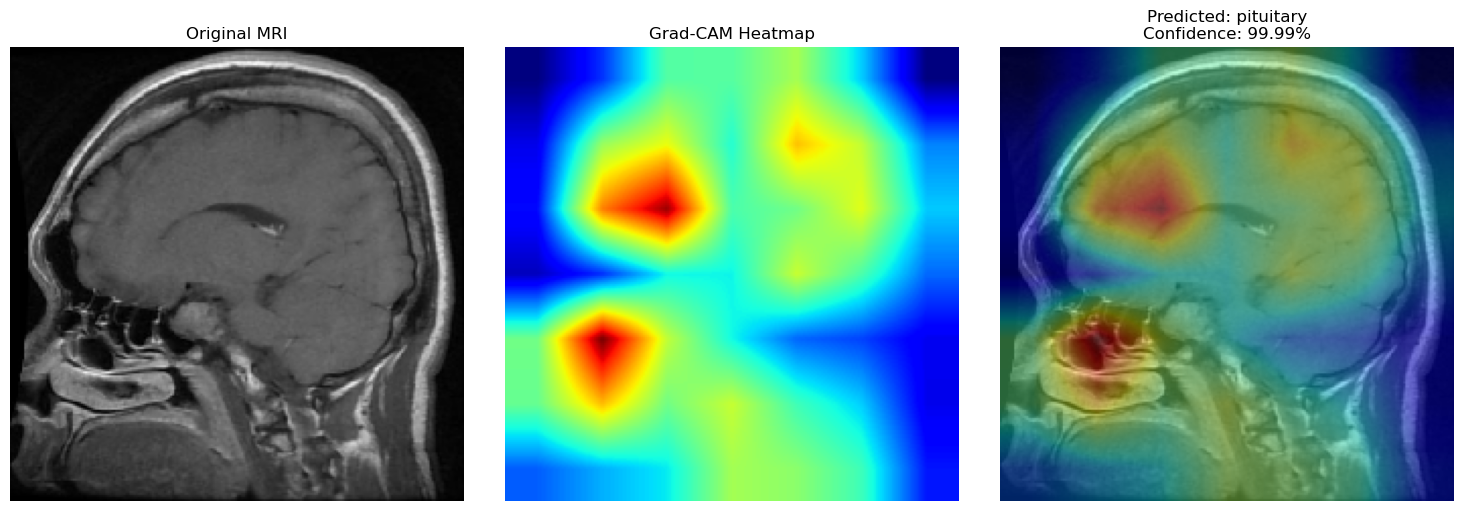

Predicted class: pituitary
Confidence: 99.99%


In [31]:
for image_path in samples:

    actual_class = test_df.loc[
        test_df["filepath"] == image_path,
        "label"
    ].iloc[0]

    print("\n" + "=" * 60)

    print(
        "Actual class:",
        actual_class
    )

    predicted_class, confidence, _ = display_gradcam(
        image_path=image_path,
        model=model,
        base_model=base_model,
        class_names=CLASS_NAMES
    )

    print(
        "Predicted class:",
        predicted_class
    )

    print(
        f"Confidence: {confidence * 100:.2f}%"
    )

In [32]:
y_true_array = np.asarray(y_true)
y_pred_array = np.asarray(y_pred)

error_mask = (
    y_true_array != y_pred_array
)

error_indices = np.where(
    error_mask
)[0]

misclassified = test_df.iloc[
    error_indices
].copy()

misclassified["true_class"] = [
    CLASS_NAMES[int(i)]
    for i in y_true_array[error_mask]
]

misclassified["predicted_class"] = [
    CLASS_NAMES[int(i)]
    for i in y_pred_array[error_mask]
]

print(
    "Total misclassified images:",
    len(misclassified)
)

print(
    "\nMisclassification rate:"
)

print(
    f"{len(misclassified) / len(test_df) * 100:.2f}%"
)

print(
    "\nMost common error pairs:"
)

error_pairs = (
    misclassified
    .groupby(
        ["true_class", "predicted_class"]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

print(error_pairs)

Total misclassified images: 99

Misclassification rate:
6.92%

Most common error pairs:
true_class  predicted_class
glioma      meningioma         39
meningioma  pituitary          30
            glioma             13
glioma      pituitary           5
notumor     meningioma          4
meningioma  notumor             2
notumor     pituitary           2
pituitary   notumor             2
notumor     glioma              1
pituitary   meningioma          1
dtype: int64


In [33]:
BEST_MODEL_PATH = (
    "best_brain_tumor_model.keras"
)

FINAL_MODEL_PATH = (
    "final_brain_tumor_model.keras"
)

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

best_model.save(
    FINAL_MODEL_PATH
)

print(
    "Best model saved to:",
    FINAL_MODEL_PATH
)

Best model saved to: final_brain_tumor_model.keras


In [34]:
def predict_mri(
    image_path,
    model,
    class_names=CLASS_NAMES
):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(
        image
    )

    input_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        input_array,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(probabilities)
    )

    predicted_class = class_names[
        predicted_index
    ]

    print(
        "Predicted class:",
        predicted_class
    )

    print("\nClass probabilities:")

    for name, probability in zip(
        class_names,
        probabilities
    ):

        print(
            f"{name}: "
            f"{probability * 100:.2f}%"
        )

    return (
        predicted_class,
        probabilities
    )

In [35]:
loaded_model = tf.keras.models.load_model(
    "final_brain_tumor_model.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


In [36]:
predict_mri(
    sample_path,
    loaded_model
)

Predicted class: pituitary

Class probabilities:
glioma: 0.00%
meningioma: 0.01%
notumor: 0.00%
pituitary: 99.98%


('pituitary',
 array([2.8453331e-05, 1.2115666e-04, 1.3384625e-06, 9.9984908e-01],
       dtype=float32))

In [37]:
loaded_model = tf.keras.models.load_model(
    "final_brain_tumor_model.keras"
)

print("Model loaded successfully.")

loaded_model.summary()

Model loaded successfully.


Model: "brain_tumor_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)         │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,228,561 (27.57 MB)

 Trainable params: 1,507,252 (5.75 MB)

 Non-trainable params: 2,706,803 (10.33 MB)

 Optimizer params: 3,014,506 (11.50 MB)